In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from IPython.display import Image, display

import gc
import itertools

```python
"""
Paths:
Chunk0950                    /Chunk0950/001_007/AO2Dtree.root
Chunk1000                    [ /Chunk1000/001_005/AO2Dtree.root, /Chunk1000/006_009/AO2Dtree.root ]
Chunk1010                    [ /Chunk1010/001_005/AO2Dtree.root, /Chunk1010/006_010/AO2Dtree.root ]
Chunk1020                    /Chunk1020/001_007/AO2Dtree.root
Chunk1030                    [ /Chunk1030/001_005/AO2Dtree.root, /Chunk1030/006_011/AO2Dtree.root ]
Chunk1040                    /Chunk1040/001_007/AO2Dtree.root
Chunk1050                    [ /Chunk1050/001_005/AO2Dtree.root, /Chunk1050/006_010/AO2Dtree.root ]
Chunk1100                    [ /Chunk1100/001_005/AO2Dtree.root, /Chunk1100/006_009/AO2Dtree.root ]
Chunk1110                    /Chunk1110/001_005/AO2Dtree.root
Chunk1120                    [ /Chunk1120/001_005/AO2Dtree.root, /Chunk1120/006_011/AO2Dtree.root ]
Chunk1130                    /Chunk1130/001_008/AO2Dtree.root
Chunk1140                    [ /Chunk1140/001_006/AO2Dtree.root, /Chunk1120/007_011/AO2Dtree.root ]
Chunk1150                    /Chunk1150/001_007/AO2Dtree.root
Chunk1200                    [ /Chunk1200/001_006/AO2Dtree.root, /Chunk1120/007_011/AO2Dtree.root ]
Chunk1210                    /Chunk1210/001_008/AO2Dtree.root
Chunk1220                    /Chunk1220/001_008/AO2Dtree.root
Chunk1300                    [ /Chunk1300/001_006/AO2Dtree.root, /Chunk1300/003/AO2Dtree.root, /Chunk1300/007_010/AO2Dtree.root ]
"""
```

In [54]:
base_path = "../shared/"
which_file = "pairs"
which_chunk = "Chunk1000"
which_number = "001_005"
N_SPLITS = 10
path = base_path + "_".join([which_file, which_chunk, which_number])
file_names = [""]*N_SPLITS
for i in range(N_SPLITS):
    file_names[i] = ( path + f"_{i}.pkl" )
print(file_names)

['../shared/pairs_Chunk1000_001_005_0.pkl', '../shared/pairs_Chunk1000_001_005_1.pkl', '../shared/pairs_Chunk1000_001_005_2.pkl', '../shared/pairs_Chunk1000_001_005_3.pkl', '../shared/pairs_Chunk1000_001_005_4.pkl', '../shared/pairs_Chunk1000_001_005_5.pkl', '../shared/pairs_Chunk1000_001_005_6.pkl', '../shared/pairs_Chunk1000_001_005_7.pkl', '../shared/pairs_Chunk1000_001_005_8.pkl', '../shared/pairs_Chunk1000_001_005_9.pkl']


In [56]:
bucket = []
for item in file_names:
    bucket.append( pd.read_pickle(item)  )
    
df = pd.concat(bucket, ignore_index=True)
 # Debug
print("The starting dataframe has", len(df), "rows and ", len(df.columns), "columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"The starting dataframe occupies {memory:.2f} MB")
df.head()

The starting dataframe has 12328878 rows and  7 columns.
The starting dataframe occupies 658.43 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing
0,0,0.000003,1.794382,0.802133,0.175594,0.041904,0.276269
1,0,-0.000006,1.605683,1.023477,0.188975,0.042613,0.109627
2,0,0.000002,2.346870,0.587005,-0.231004,0.052481,-0.341716
3,0,-0.000006,1.749417,1.881888,0.445965,0.032538,0.115660
4,0,-0.000018,1.114883,1.315396,0.241308,0.030165,0.567023


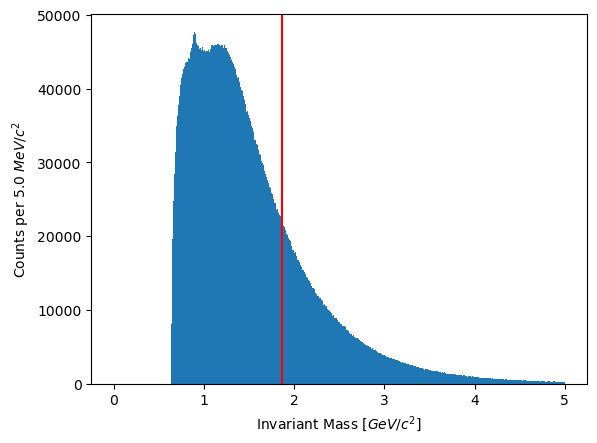

In [68]:
# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

# Variables for Plot
MIN_MASS = 0
MAX_MASS = 5
N_BINS = int(1e+03)

# Dummy plot: this takes the same collision index multiple times, with no filtering.
plt.hist(df["inv_mass"], range=(MIN_MASS,MAX_MASS), bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000)} $MeV/c^2$")
plt.show()

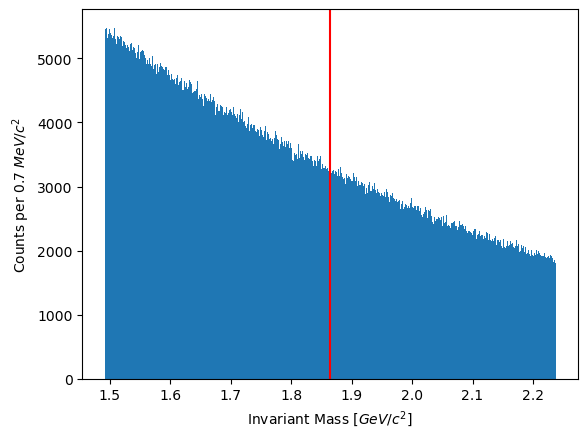

In [91]:
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
mass_mask = df["inv_mass"].between(MIN_MASS, MAX_MASS)
plt.hist(df["inv_mass"][mass_mask], range=(MIN_MASS,MAX_MASS), bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000):.1f} $MeV/c^2$")
plt.show()

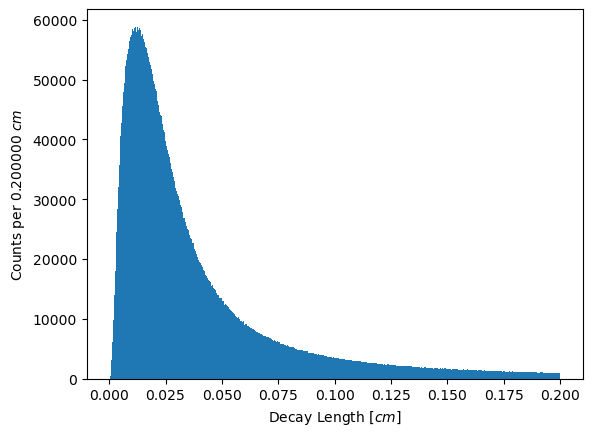

In [76]:
MIN_L, MAX_L = 0, 0.2
plt.hist(df["decay_length"], range=(MIN_L, MAX_L), bins=N_BINS)
plt.xlabel("Decay Length $[cm]$")
plt.ylabel(f"Counts per {((MAX_L-MIN_L)/N_BINS *1000):.1f} $cm$")
plt.show()

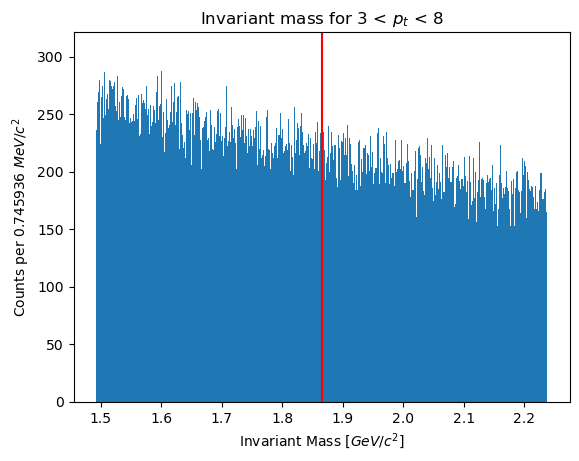

In [78]:
# pt in GeV/c
MIN_PT, MAX_PT = 3, 8
pt_mask = df["pt"].between(MIN_PT, MAX_PT)
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
plt.hist(df["inv_mass"][pt_mask],range=(MIN_MASS,MAX_MASS), bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000):.1f} $MeV/c^2$")
plt.title(f"Invariant mass for {MIN_PT} < $p_t$ < {MAX_PT}")
plt.show()

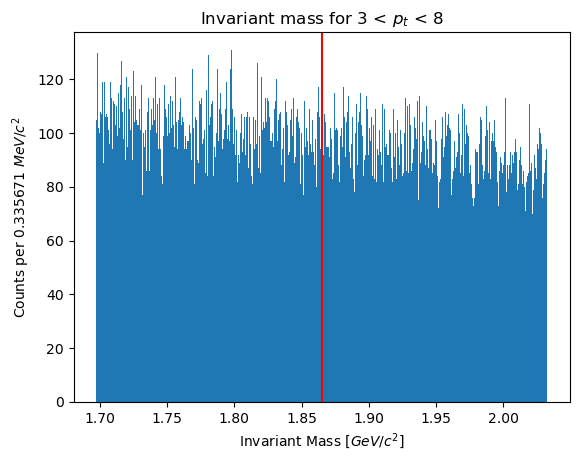

In [84]:
MIN_PT, MAX_PT = 3, 8
pt_mask = df["pt"].between(MIN_PT, MAX_PT)
MIN_MASS, MAX_MASS = 0.91*m_d0, 1.09*m_d0
plt.hist(df["inv_mass"][pt_mask],range=(MIN_MASS,MAX_MASS), bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000):.1f} $MeV/c^2$")
plt.title(f"Invariant mass for {MIN_PT} < $p_t$ < {MAX_PT}")
plt.show()

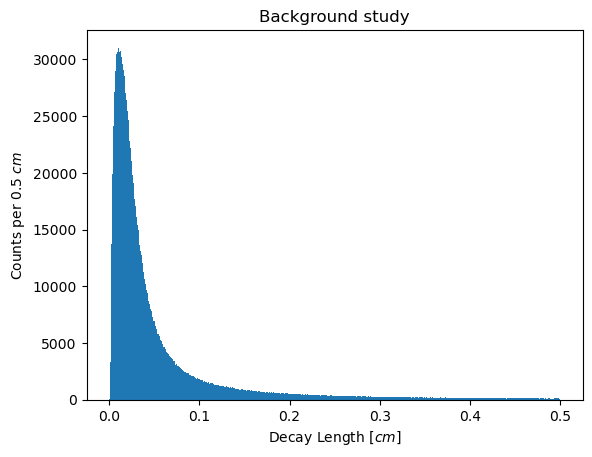

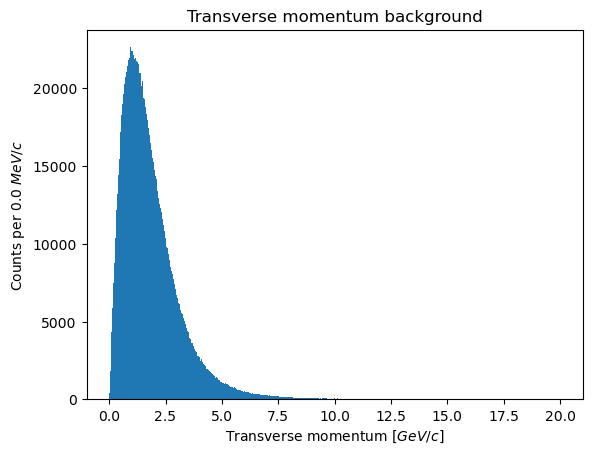

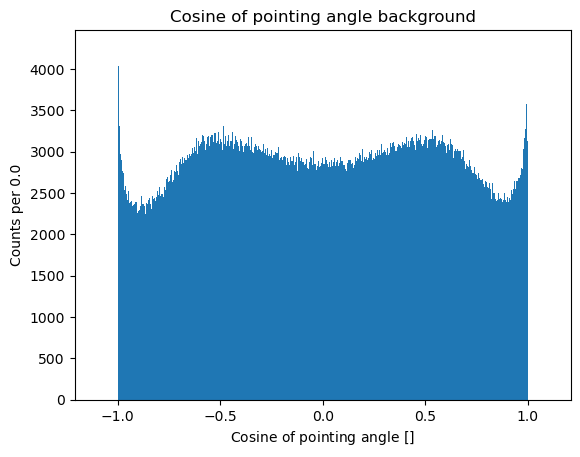

In [95]:
# Following the suggestion in the slides: for Mass > 1.94 Gev/c^2 we should have only background, so we check out how the other variables
# behave in this region with (little to) no signal
bkg_mass_mask = df["inv_mass"] > 1.94
df_bkg = df[bkg_mass_mask]

MIN_L, MAX_L = 0, 0.5
plt.hist(df_bkg["decay_length"], range=(MIN_L,MAX_L),bins=N_BINS)
plt.xlabel("Decay Length $[cm]$")
plt.ylabel(f"Counts per {((MAX_L-MIN_L)/N_BINS *1000):.1f} $cm$")
plt.title("Background study")
plt.show()

MIN_PT, MAX_PT = 0, 20
plt.hist(df_bkg["pt"], range=(MIN_PT,MAX_PT), bins=N_BINS)
plt.xlabel("Transverse momentum $[GeV/c]$")
plt.ylabel(f"Counts per {((MAX_PT-MIN_PT)/N_BINS):.1f} $MeV/c$")
plt.title(f"Transverse momentum background")
plt.show()

plt.hist(df_bkg["cos_pointing"], range=(-1.1,1.1), bins=N_BINS)
plt.xlabel("Cosine of pointing angle $[ ]$")
plt.ylabel(f"Counts per {(2/N_BINS):.1f}")
plt.title(f"Cosine of pointing angle background")
plt.show()

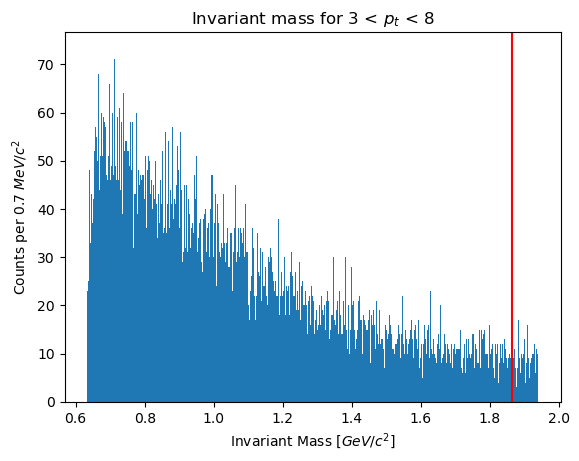

In [100]:
MIN_PT, MAX_PT = 3, 8

decay_mask = df["decay_length"] > 0.1
pointing_mask = abs(df["cos_pointing"] > 0.6)
momentum_mask = df["pt"].between(MIN_PT,MAX_PT)
mass_mask = df["inv_mass"] < 1.94

signal = df[mass_mask & decay_mask & pointing_mask & momentum_mask]
plt.hist(signal["inv_mass"][pt_mask], bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000):.1f} $MeV/c^2$")
plt.title(f"Invariant mass for {MIN_PT} < $p_t$ < {MAX_PT}")
plt.show()

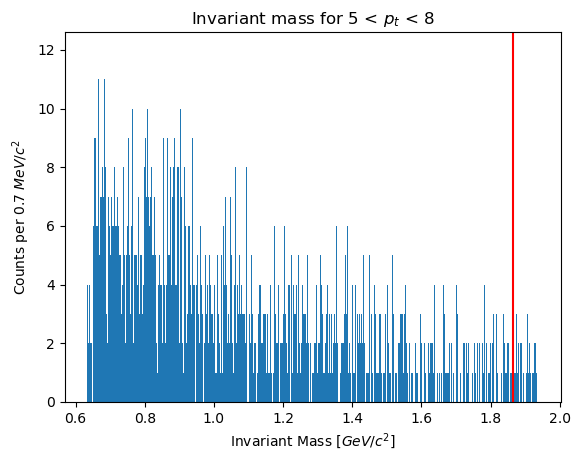

In [102]:
MIN_PT, MAX_PT = 5, 8
decay_mask = df["decay_length"] > 0.1
pointing_mask = abs(df["cos_pointing"] > 0.9)
momentum_mask = df["pt"].between(MIN_PT,MAX_PT)
mass_mask = df["inv_mass"] < 1.94

signal = df[mass_mask & decay_mask & pointing_mask & momentum_mask]
plt.hist(signal["inv_mass"][pt_mask], bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000):.1f} $MeV/c^2$")
plt.title(f"Invariant mass for {MIN_PT} < $p_t$ < {MAX_PT}")
plt.show()